In [1]:
import os
import json
import time
import random
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, roc_auc_score, confusion_matrix,
    roc_curve, precision_recall_curve, auc
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.19.0
GPUs: []


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

ROOT = Path.cwd()
PROJECT_ROOT = ROOT / "19042026"

E00_ROOT = PROJECT_ROOT / "E00_hyperparameter_tuning"
E01_ROOT = PROJECT_ROOT / "E01_resnet50_baseline"
EXP_ROOT = PROJECT_ROOT / "E02_class_imbalance"

THRESHOLD = 0.50

# Best E01 variant confirmed by your result
SOURCE_E01_RUN = "E01b_baseline_segmented"

RUNS = [
    {"run_name": "E02_weighted_bce", "mode": "weighted_bce"},
    {"run_name": "E02_focal_loss", "mode": "focal_loss"},
    {"run_name": "E02_class_balanced_bce", "mode": "class_balanced_bce"},
]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("E00_ROOT:", E00_ROOT)
print("E01_ROOT:", E01_ROOT)
print("EXP_ROOT:", EXP_ROOT)
print("SOURCE_E01_RUN:", SOURCE_E01_RUN)

PROJECT_ROOT: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026
E00_ROOT: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\E00_hyperparameter_tuning
E01_ROOT: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\E01_resnet50_baseline
EXP_ROOT: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\E02_class_imbalance
SOURCE_E01_RUN: E01b_baseline_segmented


In [3]:
SUBDIRS = [
    "configs",
    "models",
    "histories",
    "metrics",
    "predictions",
    "plots",
    "confusion_matrices",
    "logs",
    "summary"
]

for sub in SUBDIRS:
    (EXP_ROOT / sub).mkdir(parents=True, exist_ok=True)

for run in RUNS:
    run_name = run["run_name"]
    for sub in ["models", "histories", "metrics", "predictions", "plots", "confusion_matrices"]:
        (EXP_ROOT / sub / run_name).mkdir(parents=True, exist_ok=True)

print("Folders ready.")

Folders ready.


In [4]:
def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4)

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def evaluate_binary(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)

    try:
        roc = roc_auc_score(y_true, y_prob)
    except:
        roc = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "kappa": float(kappa),
        "roc_auc": float(roc) if not np.isnan(roc) else None,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "threshold": float(threshold)
    }

def plot_confusion(cm, title, save_path):
    fig, ax = plt.subplots(figsize=(5, 4))
    labels = ["Non-Melanoma", "Melanoma"]
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(2))
    ax.set_yticks(range(2))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

def plot_history(history, save_dir, run_name):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(7, 5))
    plt.plot(hist["accuracy"], label="Train Accuracy")
    plt.plot(hist["val_accuracy"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy - {run_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{run_name}_accuracy.png", dpi=300, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(7, 5))
    plt.plot(hist["loss"], label="Train Loss")
    plt.plot(hist["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss - {run_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{run_name}_loss.png", dpi=300, bbox_inches="tight")
    plt.close()

def plot_roc_pr(y_true, y_prob, save_dir, run_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC - {run_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{run_name}_roc.png", dpi=300, bbox_inches="tight")
    plt.close()

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve - {run_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{run_name}_pr.png", dpi=300, bbox_inches="tight")
    plt.close()

In [5]:
best_cfg_path = E00_ROOT / "summary" / "best_config.json"
if not best_cfg_path.exists():
    raise FileNotFoundError("E00 best_config.json not found.")

best_cfg = load_json(best_cfg_path)
best_hparams = best_cfg["best_config"]

X_train_path = E01_ROOT / "feature_cache" / SOURCE_E01_RUN / "X_train.npy"
y_train_path = E01_ROOT / "feature_cache" / SOURCE_E01_RUN / "y_train.npy"
X_val_path   = E01_ROOT / "feature_cache" / SOURCE_E01_RUN / "X_val.npy"
y_val_path   = E01_ROOT / "feature_cache" / SOURCE_E01_RUN / "y_val.npy"
X_test_path  = E01_ROOT / "feature_cache" / SOURCE_E01_RUN / "X_test.npy"
y_test_path  = E01_ROOT / "feature_cache" / SOURCE_E01_RUN / "y_test.npy"

required_paths = [X_train_path, y_train_path, X_val_path, y_val_path, X_test_path, y_test_path]
for p in required_paths:
    if not p.exists():
        raise FileNotFoundError(f"Missing cached feature file: {p}")

X_train = np.load(X_train_path)
y_train = np.load(y_train_path)
X_val   = np.load(X_val_path)
y_val   = np.load(y_val_path)
X_test  = np.load(X_test_path)
y_test  = np.load(y_test_path)

test_split_df = pd.read_csv(E00_ROOT / "summary" / "test_split.csv")

print("Best E00 config:")
print(json.dumps(best_cfg, indent=4))

print("Loaded cached features from:", SOURCE_E01_RUN)
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

Best E00 config:
{
    "best_by": "f1",
    "sort_column": "test_f1",
    "best_run_name": "run_004_du256_do04_lr5e-05_bs16",
    "best_config": {
        "dense_units": 256,
        "dropout": 0.4,
        "lr": 5e-05,
        "batch_size": 16,
        "epochs": 15
    },
    "best_test_metrics": {
        "accuracy": 0.982874617737003,
        "precision": 0.75,
        "recall": 0.05172413793103448,
        "f1": 0.0967741935483871,
        "kappa": 0.0947022879629813,
        "roc_auc": 0.8362176321552798,
        "tn": 3211,
        "fp": 1,
        "fn": 55,
        "tp": 3
    }
}
Loaded cached features from: E01b_baseline_segmented
X_train: (26154, 2048) y_train: (26154,)
X_val: (3269, 2048) y_val: (3269,)
X_test: (3270, 2048) y_test: (3270,)


In [6]:
num_neg = int((y_train == 0).sum())
num_pos = int((y_train == 1).sum())

print("Training class counts:")
print("Non-melanoma (0):", num_neg)
print("Melanoma (1):", num_pos)

# Standard class weights
total = len(y_train)
class_weights = {
    0: total / (2.0 * num_neg),
    1: total / (2.0 * num_pos)
}

print("Standard class weights:", class_weights)

# Effective number class-balanced weights
def effective_num_weight(n, beta=0.9999):
    return (1.0 - beta) / (1.0 - (beta ** n))

cb_w0 = effective_num_weight(num_neg, beta=0.9999)
cb_w1 = effective_num_weight(num_pos, beta=0.9999)

# normalize for stability
s = cb_w0 + cb_w1
cb_class_weights = {
    0: 2.0 * cb_w0 / s,
    1: 2.0 * cb_w1 / s
}

print("Class-balanced weights:", cb_class_weights)

Training class counts:
Non-melanoma (0): 25689
Melanoma (1): 465
Standard class weights: {0: 0.5090505663902838, 1: 28.12258064516129}
Class-balanced weights: {0: 0.09379925454519228, 1: 1.9062007454548076}


In [7]:
def binary_focal_loss(gamma=2.0, alpha=0.75):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        pt = tf.where(tf.equal(y_true, 1.0), y_pred, 1.0 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1.0), alpha, 1.0 - alpha)

        focal = -alpha_t * tf.pow(1.0 - pt, gamma) * tf.math.log(pt)
        return tf.reduce_mean(focal)
    return loss

def build_head_model(feature_dim, dense_units, dropout, lr, mode="weighted_bce"):
    model = keras.Sequential([
        layers.Input(shape=(feature_dim,)),
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid")
    ])

    if mode == "focal_loss":
        loss_fn = binary_focal_loss(gamma=2.0, alpha=0.75)
    else:
        loss_fn = "binary_crossentropy"

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=loss_fn,
        metrics=["accuracy"]
    )
    return model

In [8]:
all_results = []

for run in RUNS:
    run_name = run["run_name"]
    mode = run["mode"]

    print("\n" + "=" * 90)
    print("Running:", run_name)
    print("Mode:", mode)

    run_start = time.time()

    model = build_head_model(
        feature_dim=X_train.shape[1],
        dense_units=best_hparams["dense_units"],
        dropout=best_hparams["dropout"],
        lr=best_hparams["lr"],
        mode=mode
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1
        )
    ]

    fit_kwargs = {
        "x": X_train,
        "y": y_train,
        "validation_data": (X_val, y_val),
        "epochs": best_hparams["epochs"],
        "batch_size": best_hparams["batch_size"],
        "verbose": 1,
        "callbacks": callbacks
    }

    if mode == "weighted_bce":
        fit_kwargs["class_weight"] = class_weights

    if mode == "class_balanced_bce":
        fit_kwargs["class_weight"] = cb_class_weights

    history = model.fit(**fit_kwargs)

    runtime_sec = time.time() - run_start

    model.save(EXP_ROOT / "models" / run_name / f"{run_name}.keras")

    hist_df = pd.DataFrame(history.history)
    hist_df.to_csv(EXP_ROOT / "histories" / run_name / f"{run_name}_history.csv", index=False)
    plot_history(history, EXP_ROOT / "plots" / run_name, run_name)

    y_val_prob = model.predict(X_val, batch_size=best_hparams["batch_size"], verbose=0).ravel()
    y_test_prob = model.predict(X_test, batch_size=best_hparams["batch_size"], verbose=0).ravel()

    val_metrics = evaluate_binary(y_val, y_val_prob, threshold=THRESHOLD)
    test_metrics = evaluate_binary(y_test, y_test_prob, threshold=THRESHOLD)

    pred_df = pd.DataFrame({
        "image_name": test_split_df["image_name"].values,
        "true_label": y_test,
        "pred_prob": y_test_prob,
        "pred_label": (y_test_prob >= THRESHOLD).astype(int)
    })
    pred_df.to_csv(EXP_ROOT / "predictions" / run_name / f"{run_name}_test_predictions.csv", index=False)

    metrics_package = {
        "run_name": run_name,
        "mode": mode,
        "source_e01_run": SOURCE_E01_RUN,
        "best_hyperparameters_from_E00": best_hparams,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "runtime_sec": round(runtime_sec, 2)
    }
    save_json(metrics_package, EXP_ROOT / "metrics" / run_name / f"{run_name}_metrics.json")

    cm = confusion_matrix(y_test, (y_test_prob >= THRESHOLD).astype(int), labels=[0, 1])
    plot_confusion(
        cm,
        title=f"Confusion Matrix - {run_name}",
        save_path=EXP_ROOT / "confusion_matrices" / run_name / f"{run_name}_cm.png"
    )

    plot_roc_pr(y_test, y_test_prob, EXP_ROOT / "plots" / run_name, run_name)

    row = {
        "run_name": run_name,
        "mode": mode,
        "source_e01_run": SOURCE_E01_RUN,
        "accuracy": test_metrics["accuracy"],
        "precision": test_metrics["precision"],
        "recall": test_metrics["recall"],
        "f1": test_metrics["f1"],
        "kappa": test_metrics["kappa"],
        "roc_auc": test_metrics["roc_auc"],
        "tn": test_metrics["tn"],
        "fp": test_metrics["fp"],
        "fn": test_metrics["fn"],
        "tp": test_metrics["tp"],
        "runtime_sec": round(runtime_sec, 2)
    }
    all_results.append(row)

results_df = pd.DataFrame(all_results)
results_df.to_csv(EXP_ROOT / "summary" / "E02_results_comparison.csv", index=False)
results_df


Running: E02_weighted_bce
Mode: weighted_bce
Epoch 1/15
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6713 - loss: 0.8077 - val_accuracy: 0.8382 - val_loss: 0.3626
Epoch 2/15
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7182 - loss: 0.5303 - val_accuracy: 0.8798 - val_loss: 0.2982
Epoch 3/15
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7313 - loss: 0.5068 - val_accuracy: 0.8749 - val_loss: 0.3159
Epoch 4/15
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7470 - loss: 0.4751 - val_accuracy: 0.8767 - val_loss: 0.3018
Epoch 5/15
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7655 - loss: 0.4505 - val_accuracy: 0.8715 - val_loss: 0.3004
Epoch 6/15
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7761 - loss: 0.4315 - val_accuracy: 0.8856 - val_loss: 0.2806
Epoch 7/15
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7853 - loss: 0.4178 - val_accuracy: 0.8697 - val_loss: 0.3023
Epoch 8/15
1635/1635 ━━━━━━━━━━━━━━━━

,run_name,mode,source_e01_run,accuracy,precision,recall,f1,kappa,roc_auc,tn,fp,fn,tp,runtime_sec
0,E02_weighted_bce,weighted_bce,E01b_baseline_segmented,0.924771,0.087719,0.344828,0.139860,0.114827,0.825707,3004,208,38,20,167.41
1,E02_focal_loss,focal_loss,E01b_baseline_segmented,0.982875,1.000000,0.034483,0.066667,0.065562,0.826835,3212,0,56,2,68.63
2,E02_class_balanced_bce,class_balanced_bce,E01b_baseline_segmented,0.959633,0.122449,0.206897,0.153846,0.134560,0.830571,3126,86,46,12,170.56


In [9]:
results_sorted = results_df.sort_values(by=["f1", "recall", "kappa"], ascending=False).reset_index(drop=True)
best_e02 = results_sorted.iloc[0].to_dict()

save_json(best_e02, EXP_ROOT / "summary" / "best_E02_variant.json")

print("Best E02 variant:")
print(json.dumps(best_e02, indent=4))

Best E02 variant:
{
    "run_name": "E02_class_balanced_bce",
    "mode": "class_balanced_bce",
    "source_e01_run": "E01b_baseline_segmented",
    "accuracy": 0.9596330275229358,
    "precision": 0.12244897959183673,
    "recall": 0.20689655172413793,
    "f1": 0.15384615384615385,
    "kappa": 0.1345598614140896,
    "roc_auc": 0.8305707046850174,
    "tn": 3126,
    "fp": 86,
    "fn": 46,
    "tp": 12,
    "runtime_sec": 170.56
}


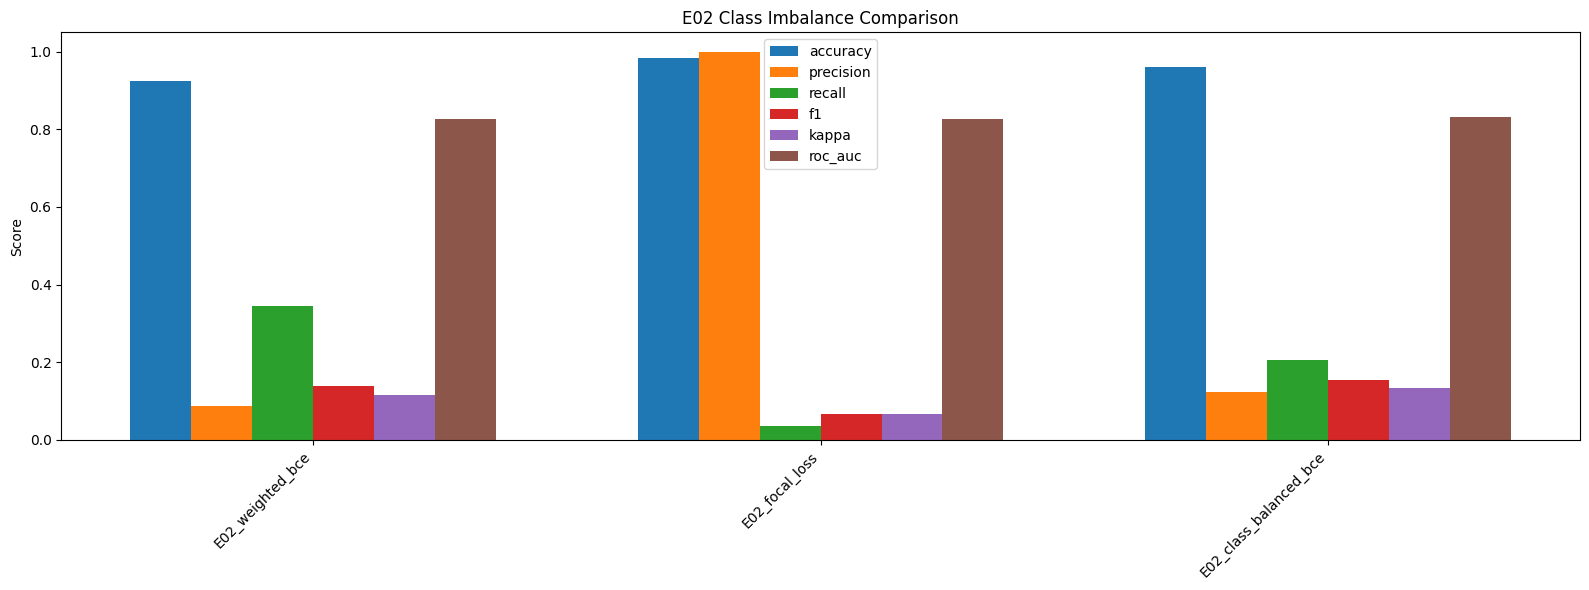

In [10]:
if len(results_df) > 0:
    plot_cols = ["accuracy", "precision", "recall", "f1", "kappa", "roc_auc"]
    plot_df = results_df[["run_name"] + plot_cols].copy()

    x = np.arange(len(plot_df))
    width = 0.12

    plt.figure(figsize=(16, 6))
    for idx, col in enumerate(plot_cols):
        plt.bar(x + idx * width, plot_df[col].fillna(0), width=width, label=col)

    plt.xticks(x + width * (len(plot_cols)-1) / 2, plot_df["run_name"], rotation=45, ha="right")
    plt.ylabel("Score")
    plt.title("E02 Class Imbalance Comparison")
    plt.legend()
    plt.tight_layout()
    plt.savefig(EXP_ROOT / "plots" / "E02_metrics_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

In [11]:
manifest = {
    "experiment_id": "E02",
    "experiment_name": "Class Imbalance Optimization",
    "date_created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "project_root": str(PROJECT_ROOT),
    "experiment_root": str(EXP_ROOT),
    "source_e01_run": SOURCE_E01_RUN,
    "best_hyperparameters_from_E00": best_hparams,
    "threshold": THRESHOLD,
    "runs": RUNS,
    "class_weights": class_weights,
    "class_balanced_weights": cb_class_weights
}
save_json(manifest, EXP_ROOT / "summary" / "experiment_manifest.json")
print("E02 finished.")

E02 finished.
